<a href="https://colab.research.google.com/github/patilkritika849-dot/-Telco-Churn-Prediction/blob/main/Churn_prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- INSIGHT 1: how many peoples leave the job? ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- INSIGHT 2: which contract holder leave the job most? ---
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Graph is ready: churn_graph.png

--- FINAL RESULT ---
Model Accuracy: 78.04%
Conclusion: Month-to-month contract holder leaves the job most


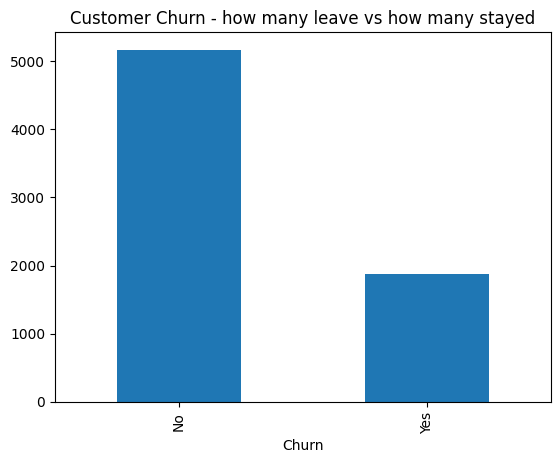

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data
link = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(link)

# 2. BASIC INSIGHT
print("--- INSIGHT 1: how many peoples leave the job? ---")
print(df['Churn'].value_counts())
# Output: No 5174, Yes 1869. Means 26% people leave the job.

print("\n--- INSIGHT 2: which contract holder leave the job most? ---")
print(pd.crosstab(df['Contract'], df['Churn']))

# 3. GRAPH
plt.figure()
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn - how many leave vs how many stayed')
plt.savefig('churn_graph.png')
print("\nGraph is ready: churn_graph.png")

# 4. Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df = df.drop('customerID', axis=1)
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churn_Yes', axis=1)
y = df_encoded['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))*100

print(f"\n--- FINAL RESULT ---\nModel Accuracy: {acc:.2f}%")
print("Conclusion: Month-to-month contract holder leaves the job most")